# Edge colouring of complete tripartite graphs with z3

In [1]:
import time
import pygraphviz as pgv
from z3 import *

## 1. Build a complete tripartite graph K(l, m, n)

`create_graph` returns the edge list; `build_graph` wraps it in a pygraphviz `AGraph`.

In [2]:
def create_graph(l, m, n):
    """Edges of the complete tripartite graph K(l, m, n)."""
    edges = []
    for i in range(0, l):
        for j in range(l, l + m):
            edges.append((i, j))
    for i in range(0, l):
        for k in range(l + m, l + m + n):
            edges.append((i, k))
    for j in range(l, l + m):
        for k in range(l + m, l + m + n):
            edges.append((j, k))
    return edges
    

In [3]:
def build_graph(l, m, n):
    """Build the AGraph for K(l, m, n). Returns (graph, name, layout)."""
    G = pgv.AGraph()
    G.node_attr['style'] = 'filled'
    G.edge_attr['dir'] = 'none'

    edges = create_graph(l, m, n)
    for i in range(l + m + n):
        G.add_node(i)
    for src, dst in edges:
        G.add_edge(src, dst)

    return (G, 'k_%d_%d_%d' % (l, m, n), 'circo')

## 2. Edge helpers

Edges are represented as `"a b"` strings. `all_edges` lists them; `node_nbs` returns every edge that shares an endpoint with the given edge (i.e. its neighbours in the line graph).

In [4]:
def all_edges(graph):
    """All edges of `graph` as 'a b' strings."""
    edges = []
    for i in range(graph.number_of_edges()):
        u, v = graph.edges()[i]
        edges.append(u + ' ' + v)
    return edges

#all_edges(graph)

In [5]:
def node_nbs(graph, edge):
    """Edges adjacent to `edge` (sharing either endpoint)."""
    neighbor_edges = []
    rev = edge.split(' ')[1] + ' ' + edge.split(' ')[0]   # true reverse edge (token swap)
    for j in range(2):
        node = edge.split(' ')[j]
        for nb in graph.neighbors(node):
            nb_edge = node + ' ' + nb
            if nb_edge != edge and nb_edge != rev:
                neighbor_edges.append(nb_edge)
    return neighbor_edges

## 3. Interval (consecutive) edge colouring with z3

A **correct colouring** must satisfy two conditions at every vertex:
1. the edges meeting there all get **different** colours, and
2. those colours form a **consecutive run** with no gaps (e.g. 2,3,4,5), i.e. `max - min == degree - 1`.

This is *interval edge colouring*. Δ (max degree) is the lower bound,the search goes from Δ upward and may report that none exists.

In [6]:
def interval_coloring(graph, max_colors=None):
    """Interval edge colouring with z3.

    (1) incident edges are all different
    (2) their colours are CONSECUTIVE (max - min == degree - 1).
    Searches k = Delta, Delta+1, ... up to max_colors (default 2*Delta).

    Returns a result dict:
      {'solution': {edge:colour} or None, 'colorable': bool,
       'colours': k or None, 'colours_tested': int,
       'delta': int, 'max_colors': int}
    """
    edges = all_edges(graph)
    idx = {e: i for i, e in enumerate(edges)}
    xs = [Int('e%d' % i) for i in range(len(edges))]

    inc = {}
    for i, e in enumerate(edges):
        u, v = e.split(' ')
        inc.setdefault(u, []).append(i)
        inc.setdefault(v, []).append(i)

    delta = max(len(es) for es in inc.values())
    if max_colors is None:
        max_colors = 2 * delta

    def zmax(lst):
        m = lst[0]
        for e in lst[1:]:
            m = If(e > m, e, m)
        return m

    def zmin(lst):
        m = lst[0]
        for e in lst[1:]:
            m = If(e < m, e, m)
        return m

    tested = 0
    for k in range(delta, max_colors + 1):
        tested += 1
        s = Solver()
        for x in xs:
            s.add(x >= 0, x <= k - 1)
        for v, es in inc.items():
            vs = [xs[i] for i in es]
            s.add(Distinct(vs))                             # condition 1
            if len(vs) > 1:
                s.add(zmax(vs) - zmin(vs) == len(vs) - 1)   # condition 2
        if s.check() == sat:
            print('OK, interval colouring found with %d colours' % k)
            m = s.model()
            sol = {e: m[xs[idx[e]]].as_long() for e in edges}
            return {'solution': sol, 'colorable': True, 'colours': k,
                    'colours_tested': tested, 'delta': delta, 'max_colors': max_colors}

    print('No interval colouring found with up to %d colours' % max_colors)
    return {'solution': None, 'colorable': False, 'colours': None,
            'colours_tested': tested, 'delta': delta, 'max_colors': max_colors}

## 3b. Solution → matrix

`color_matrix` turns an edge-colour solution into a matrix, `*` marks cells with no edge, including the diagonal. `format_matrix` renders it as aligned text for saving/printing.

In [7]:
def color_matrix(graph, solution):
    """edge-colour matrix; '*' where there is no edge."""
    nodes = sorted(graph.nodes(), key=int)
    idx = {node: i for i, node in enumerate(nodes)}
    M = [['*'] * len(nodes) for _ in nodes]
    for e_str, color in solution.items():
        u, v = e_str.split(' ')
        M[idx[u]][idx[v]] = str(color)
        M[idx[v]][idx[u]] = str(color)
    return nodes, M


def format_matrix(nodes, M):
    """Render the matrix as aligned text with node labels on row/col."""
    w = max([len(x) for row in M for x in row] + [len(x) for x in nodes]) + 1
    lines = [' ' * w + ''.join(x.rjust(w) for x in nodes)]
    for label, row in zip(nodes, M):
        lines.append(label.rjust(w) + ''.join(x.rjust(w) for x in row))
    return '\n'.join(lines)


def format_kmn(name, solution):
    """
    Rows = part A (size l) then part B (size m); columns = part A (size l)
    then part C (size n). '*' marks no-edge cells (the A x A block).
    """
    l, m, n = (int(t) for t in name.split('_')[1:])
    row_nodes = [str(v) for v in range(l + m)]                              # A, then B
    col_nodes = [str(v) for v in list(range(l)) + list(range(l + m, l + m + n))]  # A, then C

    def cell(u, v):
        c = solution.get(u + ' ' + v)
        if c is None:
            c = solution.get(v + ' ' + u)
        return '*' if c is None else str(c)

    grid = [[cell(r, c) for c in col_nodes] for r in row_nodes]
    w = max(len(x) for row in grid for x in row)
    rows_txt = [' ' + ' | '.join(x.rjust(w) for x in row) + ' |' for row in grid]
    width = max(len(r) for r in rows_txt)
    rule = ' ' + '-' * (width - 1)

    lines = [('K ' + ' '.join(str(s) for s in (l, m, n))).center(width), '']
    for r in rows_txt:
        lines.append(r)
        lines.append(rule)
    return '\n'.join(lines)


def render_matrix(name, graph, solution):
    parts = name.split('_')
    if parts[0] == 'k' and len(parts) == 4 and all(p.isdigit() for p in parts[1:]):
        return format_kmn(name, solution)
    nodes, M = color_matrix(graph, solution)
    return format_matrix(nodes, M)


def log_solution(name, graph, res, runtime, path='solutions.txt'):
    """Append a summary of one run to the combined solutions file: runtime,
    how many colour-counts were tested, whether the graph was colourable, and
    (if so) the solution matrix appends.
    Entries accumulate across runs."""
    
    lo = res['delta']
    hi = lo + res['colours_tested'] - 1
    lines = ['=== %s ===' % name,
             'colourable     : %s' % ('yes' if res['colorable'] else 'no'),
             'colours tested : %d  (k = %d .. %d)' % (res['colours_tested'], lo, hi),
             'runtime        : %.3f s' % runtime]
    if res['colorable']:
        lines.append('colours used   : %d' % res['colours'])
        lines.append('solution matrix:')
        lines.append(render_matrix(name, graph, res['solution']))
    lines.append('')
    with open(path, 'a') as f:
        f.write('\n'.join(lines) + '\n')
    print('Appended result for %s to %s' % (name, path))

In [11]:
l,m,n = 2, 1,4 

## 4. Run

Build K(l, m, n) and colour its edges.

In [12]:
x, name, layout = build_graph(l, m, n)
print('Graph %r: %d nodes, %d edges' % (name, x.number_of_nodes(), x.number_of_edges()))

t1 = time.time()
res = interval_coloring(x)
t2 = time.time()
runtime = t2 - t1

if not res['colorable']:
    print('This graph has no interval colouring in the searched range.')
else:
    print('solution (in %.3fs):' % runtime)
    print(res['solution'])
    print()
    print('Minimum colours for an interval colouring: %d' % res['colours'])
    print('  (max degree Delta = %d is a hard lower bound)' % res['delta'])
    print('Colour counts tested: %d (searched upward from Delta)' % res['colours_tested'])

# save this run to the combined solutions file
log_solution(name, x, res, runtime)

Graph 'k_2_1_4': 7 nodes, 14 edges
OK, interval colouring found with 6 colours
solution (in 0.134s):
{'0 2': 4, '0 3': 0, '0 4': 1, '0 5': 2, '0 6': 3, '1 2': 0, '1 3': 1, '1 4': 2, '1 5': 3, '1 6': 4, '2 3': 2, '2 4': 3, '2 5': 1, '2 6': 5}

Minimum colours for an interval colouring: 6
  (max degree Delta = 6 is a hard lower bound)
Colour counts tested: 1 (searched upward from Delta)
Appended result for k_2_1_4 to solutions.txt


## 5. Draw the coloured graph

Draws the graph with each part on its own row (same colour per row) and edges coloured + labelled with their colour number. Change `part_fill` for the node/row colours and `edge_palette` for the edge colours.

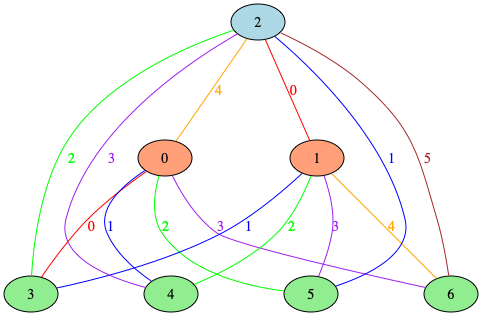

In [13]:
# Draw the coloured graph: nodes coloured by part (same row = same colour).
# Layout rules:
#   * every part sits on its own horizontal line,
#   * the part with the FEWEST nodes is pinned to the TOP (2 nodes on top),
#   * the part with the MOST nodes is pinned to the BOTTOM,
#   * generous spacing + spline routing so nodes never overlap and edges
#     curve AROUND nodes instead of crossing over them,
#   * edges coloured and labelled with their colour number.
if not res['colorable']:
    print('No colouring to draw for %s.' % name)
else:
    sol = res['solution']
    sizes = [int(t) for t in name.split('_')[1:]]      # 'k_2_3_4' -> [2, 3, 4]

    # >>> CHANGE NODE COLOURS HERE (one per row/part) <<<
    part_fill = ['lightsalmon', 'lightblue', 'lightgreen', 'khaki', 'plum']
    # >>> CHANGE EDGE COLOURS HERE (indexed by each edge's colour number) <<<
    edge_palette = ['red', 'blue', 'green', 'purple', 'orange', 'brown',
                    'cyan', 'magenta', 'darkgreen', 'gray', 'gold', 'navy']

    # node index range for each ORIGINAL part: part p owns nodes [start, start+size)
    starts, node = [], 0
    for size in sizes:
        starts.append(node)
        node += size
    part_nodes_by_part = [[str(starts[p] + i) for i in range(sizes[p])]
                          for p in range(len(sizes))]

    # vertical order of the rows: smallest part on TOP, largest part on BOTTOM
    row_order = sorted(range(len(sizes)), key=lambda p: sizes[p])
    n_rows = len(row_order)

    # spacing so nodes never overlap and edges have room to route AROUND nodes
    x.graph_attr['nodesep'] = '0.6'    # horizontal gap between nodes in a row
    x.graph_attr['ranksep'] = '1.2'    # vertical gap between rows (room for splines)
    x.graph_attr['splines'] = 'true'   # draw edges as curves that avoid nodes

    for row_pos, p in enumerate(row_order):
        part_nodes = part_nodes_by_part[p]
        for nd in part_nodes:
            n = x.get_node(nd)
            n.attr['style'] = 'filled'
            n.attr['fillcolor'] = part_fill[p % len(part_fill)]
        # top row -> rank 'min', bottom row -> rank 'max', middle rows -> 'same'
        rank = 'min' if row_pos == 0 else ('max' if row_pos == n_rows - 1 else 'same')
        sub = x.add_subgraph(part_nodes, name='row_%d' % row_pos, rank=rank)
        # invisible chain keeps the row in increasing left-to-right order
        for a, b in zip(part_nodes, part_nodes[1:]):
            sub.add_edge(a, b, style='invis')

    # colour AND number each edge
    for e_str, color in sol.items():
        u, v = e_str.split(' ')
        e = x.get_edge(u, v)
        c = edge_palette[color % len(edge_palette)]
        e.attr['color'] = c
        e.attr['fontcolor'] = c
        e.attr['label'] = str(color)

    from IPython.display import Image, display
    # prog='dot' forces the layered engine that stacks the rows.
    # (pygraphviz's draw() defaults to neato, which would scramble the rows.)
    display(Image(x.draw(prog='dot', format='png')))   # show inline (NOT saved to disk)
